In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [52]:
# Create an m x n matrix
m = 30 
n = 6

# Generate initial data with zeroes
data = np.zeros((m, n))
print(data.shape) # m rows x n columns
print(data)

(30, 6)
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [53]:
data[:, 0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [54]:

# data[:, 0] = np.random.randn(30)
# data[:, 0]

In [55]:
# data[:, 0] = data[:, 0] * 30
# data[:, 0]

In [56]:
# Now we need to fill the matrix with some random data.

for i in range(n): # for each column
    data[:, i] = 30 * np.random.randn(m)
    '''
    We are basically generating m random numbers, and using this list of m numbers
    as the new rows for column i.
    The number comes from a normal distribution (mean 0, std 1), and then we multiply each number
    by 30. Uncomment above cells for printed example.
    Multiplying by 30 scales every random value, so the mean stays 0, but std is now
    30.
    Practical effect: 
    - The data spread becomes much wider. 
    - Typical values are now tens instead of around +/- 1
    - About 68% of values are roughly between -30 and +30 (30 away from the mean)
    '''

In [57]:
data[:, 0]

array([ 31.06508414,  35.97884427,  54.46370292,   3.1733337 ,
       -33.29512637,  -8.56741701,  52.12715958,  10.57190936,
        -9.5878861 , -38.91976571, -34.34876239, -33.3204909 ,
        26.82219668,   7.88178103,  21.98828537, -22.27240835,
        10.42210108, -14.28613428, -39.34064097,   8.72660746,
        23.33907245,  -5.30770317,  -8.34891049,  20.22889781,
        45.99378466,  22.70207523, -57.81323789,  24.53317114,
       -30.24037686,  16.11396176])

In [58]:
for i in range(n):
    data[:, i] *= (2*i / (n-1) - 1) ** 2

### Above
For column $2$, for example, we multiply each value in each row by:
$$
(\frac{(2 \times 2)}{(6 - 1)} - 1)^2 \newline
= (\frac{4}{5} - 1)^2 \newline
= (0.8 - 1)^2
= -0.2^2
= 0.04
$$

- So it would always end up as something divided by 5, minus 1, squared. 
- The something is determined by which column we are currently operating on.
- As the column increases, the numerator also increases, so the number gets bigger..It evaluates as follows:
- Column 0: $(\frac{0}{5}-1)^2 = -1^2 = 1$
- Column 1: $(\frac{2}{5}-1)^2 = (0.4-1)^2 = -0.6^2 = 0.36$
- Column 2: $(\frac{4}{5}-1)^2 = (0.8-1)^2 = -0.2^2 = 0.04$
- Column 3: $(\frac{6}{5}-1)^2 = (1.2-1)^2 = 0.2^2 = 0.04$
- Column 4: $(\frac{8}{5}-1)^2 = (1.6-1)^2 = 0.6^2 = 0.36$
- Column 5: $(\frac{10}{5}-1)^2 = (2-1)^2 = 1^2 = 1$

This creates a U-shaped weighting across columns:
- edge columns stay large
- middle columns are strongly shrunk
- pattern is symmetric

This is done to impose some structure on the otherwise random data so plots look patterned rather than pure noise.

Basically, we're simulating "lots of data points on the extreme ends. not so many in the middle regions"

In [59]:
data

array([[ 3.10650841e+01, -1.44772652e+01,  5.83342358e-01,
         4.77712825e-01,  3.19440301e+00, -6.49877254e-01],
       [ 3.59788443e+01, -1.53162933e-01,  9.63927669e-01,
        -7.85972899e-03,  1.42614243e+01,  4.99079186e+01],
       [ 5.44637029e+01, -1.10011686e+01, -6.77465617e-01,
        -1.29623712e+00, -8.50375515e+00, -2.75613157e+01],
       [ 3.17333370e+00, -6.47912936e+00,  1.75190416e+00,
        -7.79554313e-01, -7.76919169e+00,  1.77664960e+01],
       [-3.32951264e+01,  6.85295512e-01, -1.11636254e+00,
         1.05048010e+00, -7.13422087e+00,  2.22823593e+01],
       [-8.56741701e+00, -9.99265559e+00, -1.28614139e+00,
        -6.38570360e-01, -3.25332036e+00,  3.47259721e+01],
       [ 5.21271596e+01,  8.82320901e+00, -9.36056377e-01,
         4.65509562e-01, -1.79539549e+01, -5.33655512e+01],
       [ 1.05719094e+01,  1.52867287e+01,  6.13902105e-01,
         5.32746642e-01,  8.27351351e+00,  1.17377108e+01],
       [-9.58788610e+00, -3.12547003e+00,  2.256

In [60]:
for i in range(n):
    data[:, i] += (i+1)**2

For each row in each column, add that column's index (in 1-based indexing) squared. 
i.e. every row in column 1 will get 1 added to it. Every row in column 2 will get 4 added to it. 
- This shifts each column upward, but does not change each column's spread by itself.

In [61]:
data

array([[ 32.06508414, -10.47726519,   9.58334236,  16.47771283,
         28.19440301,  35.35012275],
       [ 36.97884427,   3.84683707,   9.96392767,  15.99214027,
         39.26142433,  85.90791859],
       [ 55.46370292,  -7.00116861,   8.32253438,  14.70376288,
         16.49624485,   8.43868432],
       [  4.1733337 ,  -2.47912936,  10.75190416,  15.22044569,
         17.23080831,  53.76649597],
       [-32.29512637,   4.68529551,   7.88363746,  17.0504801 ,
         17.86577913,  58.28235932],
       [ -7.56741701,  -5.99265559,   7.71385861,  15.36142964,
         21.74667964,  70.72597214],
       [ 53.12715958,  12.82320901,   8.06394362,  16.46550956,
          7.0460451 , -17.36555117],
       [ 11.57190936,  19.28672873,   9.61390211,  16.53274664,
         33.27351351,  47.73771081],
       [ -8.5878861 ,   0.87452997,  11.25620572,  14.44582831,
         13.97488751,   7.52499003],
       [-37.91976571,   4.20094116,   7.87535012,  18.90631044,
         21.85273134,  77.1

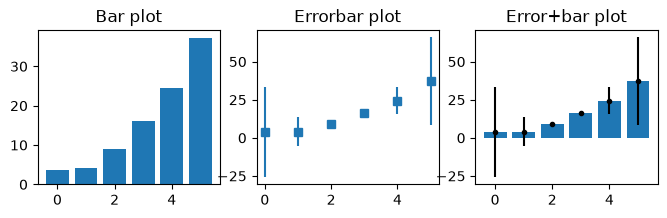

In [62]:
# show the bars!

fig,ax = plt.subplots(1,3,figsize=(8,2))

# 'naked' bars
ax[0].bar(range(n),np.mean(data,axis=0))
ax[0].set_title('Bar plot')

# just the error bars
ax[1].errorbar(range(n),np.mean(data,axis=0),np.std(data,axis=0,ddof=1),marker='s',linestyle='')
ax[1].set_title('Errorbar plot')

# both
ax[2].bar(range(n),np.mean(data,axis=0))
ax[2].errorbar(range(n),np.mean(data,axis=0),np.std(data,axis=0,ddof=1),marker='.',linestyle='',color='k')
ax[2].set_title('Error+bar plot')

plt.show()

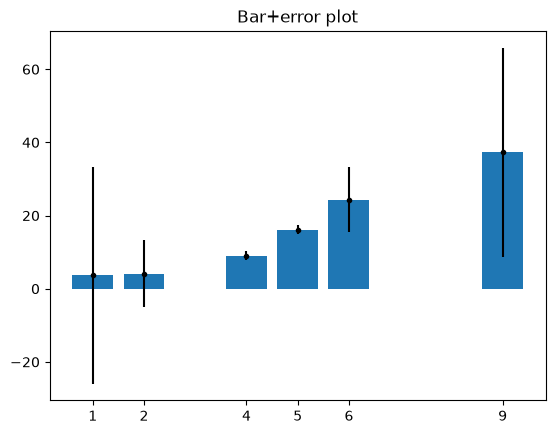

In [63]:
## manually specify x-axis coordinates

xcrossings = [ 1, 2, 4, 5, 6, 9 ]

plt.bar(xcrossings,np.mean(data,axis=0))
plt.errorbar(xcrossings,np.mean(data,axis=0),np.std(data,axis=0,ddof=1),marker='.',linestyle='',color='k')
plt.gca().set_xticks(xcrossings)
plt.title('Bar+error plot')

plt.show()